In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [ ]:
import os

# Define paths (CHANGE THIS to your actual path)
train_path = "/content/drive/MyDrive/train"
test_path = "/content/drive/MyDrive/test"

# Count images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")

# YOUR CODE HERE: Print the number of test images
# Hint: Look at the code above and modify it for test_path
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Test hot dog images: {test_hot_dog_count}")
print(f"Test not hot dog images: {test_not_hot_dog_count}")
print(f"Total test images: {test_hot_dog_count + test_not_hot_dog_count}")

Hot dog images: 249
Not hot dog images: 249
Test hot dog images: 250
Test not hot dog images: 250
Total test images: 500


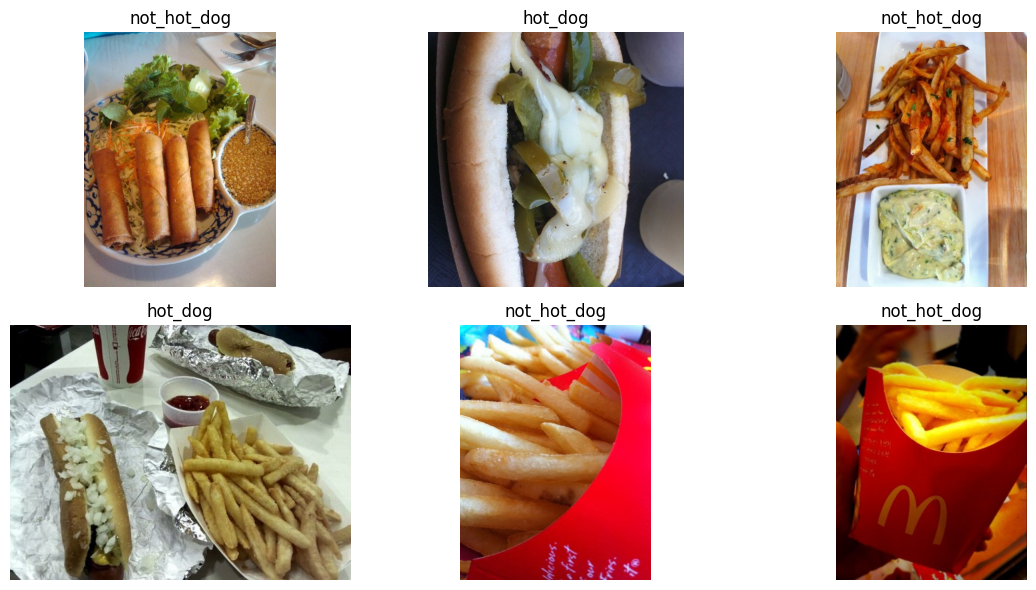

Image shape: (512, 512, 3)
Height: 512 pixels
Width: 512 pixels
Channels: 3 (RGB)


In [ ]:
# Display 6 random images
plt.figure(figsize=(12, 6))
for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')  # Fixed: straight quotes instead of curly quotes
plt.tight_layout()
plt.show()

# YOUR CODE HERE: Print the shape (height, width, channels) of one image
# Hint: Use img.shape after loading an image
# Load a sample image
sample_class = "hot_dog"
sample_path = os.path.join(train_path, sample_class)
sample_img_name = os.listdir(sample_path)[0]  # Get first image
sample_img_path = os.path.join(sample_path, sample_img_name)
sample_img = plt.imread(sample_img_path)

# Print the shape
print(f"Image shape: {sample_img.shape}")
print(f"Height: {sample_img.shape[0]} pixels")
print(f"Width: {sample_img.shape[1]} pixels")
if len(sample_img.shape) == 3:
    print(f"Channels: {sample_img.shape[2]} (RGB)")

In [ ]:
# Set image size (YOUR CHOICE: 64x64 is faster, 128x128 is moreaccurate
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
# Create generators with automatic labeling
train_datagen = ImageDataGenerator(
rescale=1./255, # Normalize pixel values from 0-255 to 0-1
validation_split=0.2 # Use 20% of training data for validation
)
train_generator = train_datagen.flow_from_directory(
train_path,
target_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
class_mode='binary', # Binary classification (hot dog vs not), # Binary classification (hot dog vs not)
subset='training' # Training set (80% of data)
)
validation_generator = train_datagen.flow_from_directory(
train_path,
target_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
class_mode='binary',
subset='validation' # Validation set (20% of data)
)
# YOUR CODE HERE: Print the class labels
#
# Hint: Print train_generator.class_indices
print(train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
{'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 279ms/step - accuracy: 0.5275 - loss: 1.1707 - val_accuracy: 0.5204 - val_loss: 0.7157
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.5225 - loss: 0.9159 - val_accuracy: 0.5918 - val_loss: 0.7041
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.6500 - loss: 0.6249 - val_accuracy: 0.5612 - val_loss: 0.7363
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.6975 - loss: 0.5759 - val_accuracy: 0.5408 - val_loss: 0.7849
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.7200 - loss: 0.5418 - val_accuracy: 0.5918 - val_loss: 0.7266
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.7675 - loss: 0.5143 - val_accuracy: 0.5306 - val_loss: 0.8038
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.7600 - loss: 0.4828 - val_accuracy: 0.5204 - val_loss: 1.0032
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.6550 - loss: 0.6102 - val_accuracy: 0.

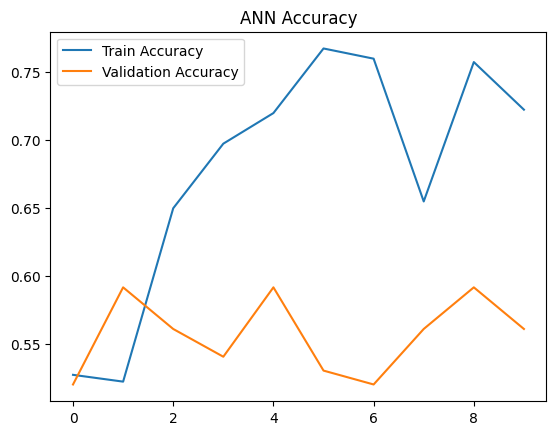

In [ ]:
# Build a simple ANN
ann_model = keras.Sequential([
# Flatten the 2D image into 1D
layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
# Dense layers
layers.Dense(128, activation='relu'),
layers.Dense(64, activation='relu'),
layers.Dense(1, activation='sigmoid') # Output: probability of "hot dog"
])

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
# Show model summary
ann_model.summary()
# Train for 10 epochs
history_ann = ann_model.fit(train_generator, validation_data=
validation_generator, epochs=10)
# YOUR CODE HERE: Plot training vs validation accuracy.
#
#
# Hint: Use
# plt.plot(history_ann.history[’XXXX’], label=’XXXX’)
# plt.plot(history_ann.history[’XXXX’], label=’XXXX’)
plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("ANN Accuracy")
plt.show()

In [ ]:
cnn_model = keras.Sequential([
# First Conv layer: 32 filters, 3x3 kernel
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
IMG_HEIGHT, IMG_WIDTH, 3)),
layers.MaxPooling2D((2, 2)),
# Second Conv layer: 64 filters
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
# Third Conv layer (YOUR TURN): Add 64 filters with 3x3 kernel,followed by Max pooling
# YOUR CODE HERE:
#
#layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
# Flatten and dense layers
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(1, activation='sigmoid'),
])
# Compile (copy from ANN)
# YOUR CODE HERE:
#
#
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#
# Hint: use optimizer = adam, loss = binary_crossentropy, and metrics= accuracy
# Train the CNN
history_cnn = cnn_model.fit(train_generator, validation_data=
validation_generator, epochs=15)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step - accuracy: 0.5475 - loss: 0.6815 - val_accuracy: 0.6327 - val_loss: 0.6592
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 488ms/step - accuracy: 0.6975 - loss: 0.6234 - val_accuracy: 0.6020 - val_loss: 0.6391
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - accuracy: 0.7050 - loss: 0.5709 - val_accuracy: 0.6633 - val_loss: 0.6930
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.7400 - loss: 0.5276 - val_accuracy: 0.5816 - val_loss: 0.6920
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - accuracy: 0.7250 - loss: 0.5216 - val_accuracy: 0.5816 - val_loss: 0.7042
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 317ms/step - accuracy: 0.7800 - loss: 0.4734 - val_accuracy: 0.6327 - val_loss: 0.6668
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step - accuracy: 0.8000 - loss: 0.4591 - val_accuracy: 0.5816 - val_loss: 0.7391
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 459ms/step - accuracy: 0.8300 - loss: 0.4241 - val_accuracy: 0.

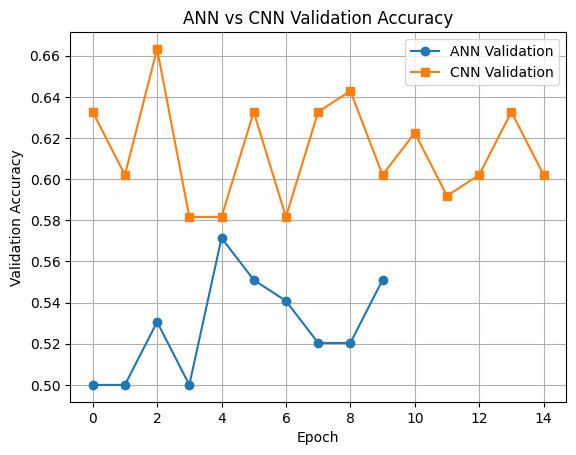

In [ ]:
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras import regularizers
# Add dropout of 0.25, 0.25, and 0.5 after each MaxPooling layer respectively
improved_model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
IMG_HEIGHT, IMG_WIDTH, 3)),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25), # Add dropout
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25), # Add dropout
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.5), # Add dropout before output
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(1, activation='sigmoid')
])
# Recompile and Train the improved model (after addressing overfitting using dropout)
improved_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
history_improved = improved_model.fit(train_generator, validation_data=validation_generator, epochs=15)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 418ms/step - accuracy: 0.5050 - loss: 0.7258 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 464ms/step - accuracy: 0.4575 - loss: 0.6990 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.5250 - loss: 0.6922 - val_accuracy: 0.5204 - val_loss: 0.6926
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 419ms/step - accuracy: 0.5275 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.5250 - loss: 0.6885 - val_accuracy: 0.5102 - val_loss: 0.6900
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 342ms/step - accuracy: 0.5550 - loss: 0.6862 - val_accuracy: 0.6224 - val_loss: 0.6857
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 454ms/step - accuracy: 0.5475 - loss: 0.6887 - val_accuracy: 0.6020 - val_loss: 0.6857
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 370ms/step - accuracy: 0.5950 - loss: 0.6717 - val_accuracy: 0.

In [ ]:
augmented_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=20,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True,
validation_split=0.2
)
train_augmented = augmented_datagen.flow_from_directory(
train_path,
target_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
class_mode='binary',
subset='training'
)
# Then retrain the improved model with augmented_datagen
final_model = keras.Sequential([
# Same architecture as improved_model
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
IMG_HEIGHT, IMG_WIDTH, 3)),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dropout(0.5),
layers.Dense(1, activation='sigmoid')
])
final_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
history_final = final_model.fit(train_augmented, validation_data=
validation_generator, epochs=15)

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 589ms/step - accuracy: 0.5050 - loss: 0.7053 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 403ms/step - accuracy: 0.5000 - loss: 0.7043 - val_accuracy: 0.5816 - val_loss: 0.6918
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 421ms/step - accuracy: 0.5550 - loss: 0.6889 - val_accuracy: 0.5510 - val_loss: 0.6908
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 497ms/step - accuracy: 0.5200 - loss: 0.6923 - val_accuracy: 0.6020 - val_loss: 0.6875
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 407ms/step - accuracy: 0.5225 - loss: 0.6887 - val_accuracy: 0.5918 - val_loss: 0.6848
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 521ms/step - accuracy: 0.5800 - loss: 0.6763 - val_accuracy: 0.6327 - val_loss: 0.6685
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 380ms/step - accuracy: 0.5700 - loss: 0.6834 - val_accuracy: 0.5612 - val_loss: 0.6833
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 552ms/step - accuracy:

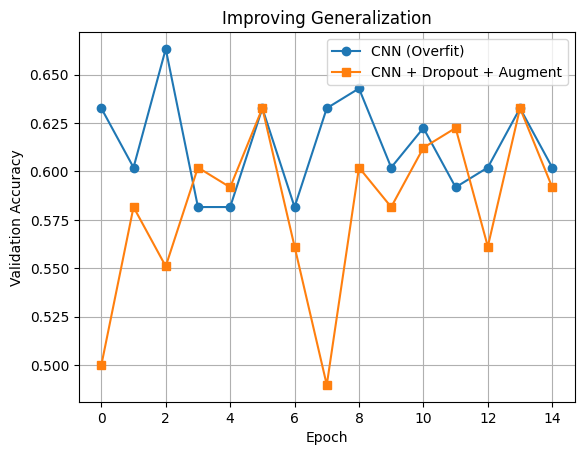

In [ ]:
plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
HOT DOG! (confidence: 0.64)


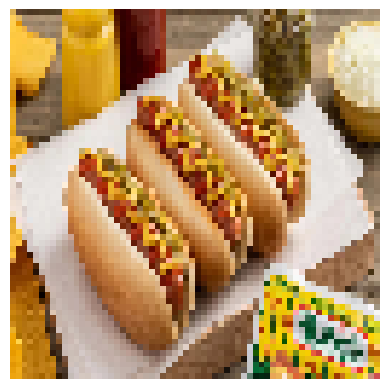

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image_from_drive(img_path):
    # Load image from Google Drive path
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = final_model.predict(img_array)[0][0]
    if prediction > 0.5:
        print(f"HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f"NOT A HOT DOG! (confidence: {1-prediction:.2f})")

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Test with an image from Google Drive
# Replace with the actual path to your image in Google Drive
predict_image_from_drive("/content/drive/MyDrive/WhatsApp Image 2026-05-03 at 5.12.59 AM.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
HOT DOG! (confidence: 0.55)


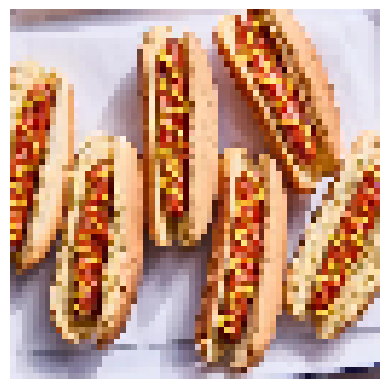

In [ ]:
predict_image_from_drive("/content/drive/MyDrive/1755026052030.webp")

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt")  # n = nano (fast, small)

# Run detection on your hot dog image
results = yolo_model("/content/drive/MyDrive/Salami-pizza-hero.avif")

# Show results (it will draw boxes around objects it recognizes)
results[0].show()

Output hidden; open in https://colab.research.google.com to view.


image 1/1 /content/drive/MyDrive/1755026052030.webp: 480x640 6 hot dogs, 166.7ms
Speed: 8.5ms preprocess, 166.7ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


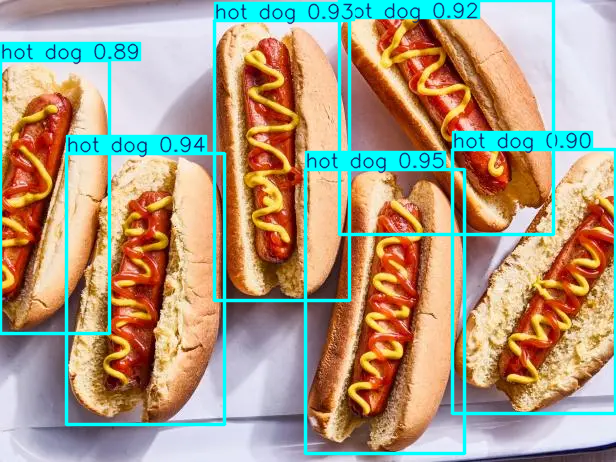

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt")  # n = nano (fast, small)

# Run detection on your hot dog image
results = yolo_model("/content/drive/MyDrive/1755026052030.webp")

# Show results (it will draw boxes around objects it recognizes)
results[0].show()